In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r'D:\InternshipTasksDatasets\global_superstore_2016.xlsx\global_superstore_2016.xlsx')

# Check data
print(df.info())
print(df.head())
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   Postal Code     9994 non-null   float64       
 9   City            51290 non-null  object        
 10  State           51290 non-null  object        
 11  Country         51290 non-null  object        
 12  Region          51290 non-null  object        
 13  Market          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [10]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Convert Order Date to datetime (already done, but confirm)
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Year and Month columns for filtering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Check summary statistics
print("\n" + "="*50)
print("SALES SUMMARY")
print("="*50)
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Number of orders: {df['Row ID'].count():,}")
print(f"Number of unique customers: {df['Customer ID'].nunique():,}")
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")

# Check regions available
print("\nRegions:", df['Region'].unique().tolist())
print("Categories:", df['Category'].unique().tolist())
print("Sub-Categories:", df['Sub-Category'].unique().tolist())

Missing values per column:
Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Postal Code       41296
City                  0
State                 0
Country               0
Region                0
Market                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

SALES SUMMARY
Total Sales: $12,642,501.91
Total Profit: $1,467,457.29
Number of orders: 51,290
Number of unique customers: 17,415
Date range: 2012-01-01 00:00:00 to 2015-12-31 00:00:00

Regions: ['Central US', 'Oceania', 'Western Europe', 'Western Africa', 'Western US', 'Southern Asia', 'Western Asia', 'South America', 'Eastern Asia', 'Southern Europe', 'Eastern Africa', 'Eastern 

In [11]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Convert Order Date to datetime (already done, but confirm)
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Year and Month columns for filtering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Check summary statistics
print("\n" + "="*50)
print("SALES SUMMARY")
print("="*50)
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Number of orders: {df['Row ID'].count():,}")
print(f"Number of unique customers: {df['Customer ID'].nunique():,}")
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")

# Check regions available
print("\nRegions:", df['Region'].unique().tolist())
print("Categories:", df['Category'].unique().tolist())
print("Sub-Categories:", df['Sub-Category'].unique().tolist())

Missing values per column:
Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Postal Code       41296
City                  0
State                 0
Country               0
Region                0
Market                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
Year                  0
Month                 0
dtype: int64

SALES SUMMARY
Total Sales: $12,642,501.91
Total Profit: $1,467,457.29
Number of orders: 51,290
Number of unique customers: 17,415
Date range: 2012-01-01 00:00:00 to 2015-12-31 00:00:00

Regions: ['Central US', 'Oceania', 'Western Europe', 'Western Africa', 'Western US', 'Southern Asia', 'Western Asia', 'South America', 'Eastern Asia'

2026-03-27 13:49:51.509 
  command:

    streamlit run D:\Anacondafiles\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-27 13:49:51.519 No runtime found, using MemoryCacheStorageManager
2026-03-27 13:49:51.540 No runtime found, using MemoryCacheStorageManager


DeltaGenerator()

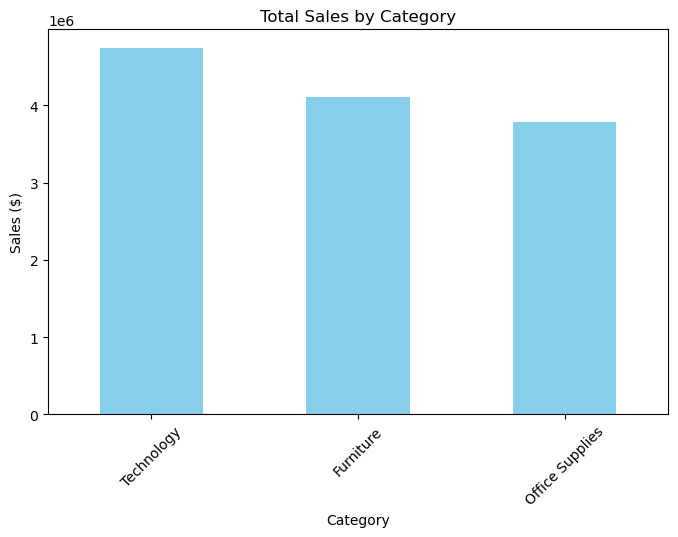

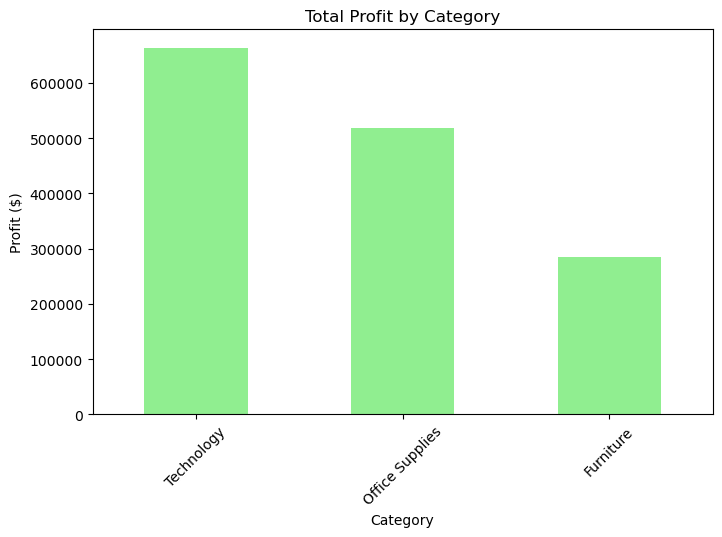

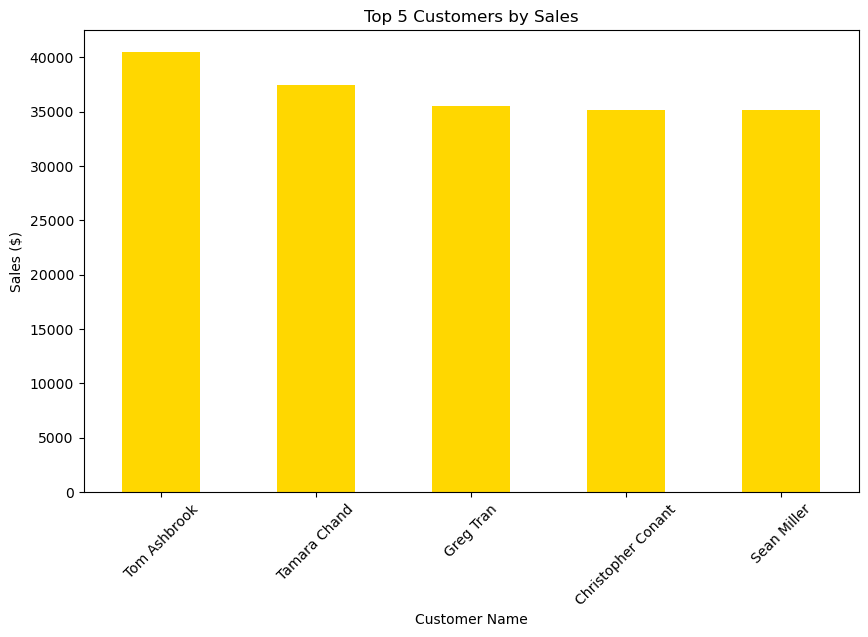

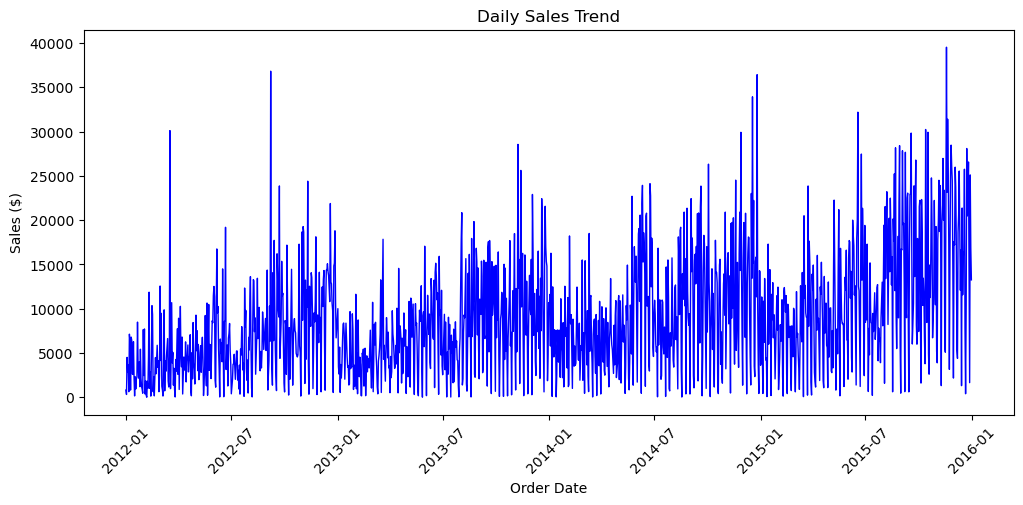

In [12]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Page configuration
st.set_page_config(page_title="Global Superstore Dashboard", layout="wide")

# Title
st.title("📊 Global Superstore Business Dashboard")
st.markdown("---")

# Load data
@st.cache_data
def load_data():
    df = pd.read_excel(r'D:\InternshipTasksDatasets\global_superstore_2016.xlsx\global_superstore_2016.xlsx')
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    return df

df = load_data()

# Sidebar filters
st.sidebar.header("🔍 Filters")

# Region filter
region_options = sorted(df['Region'].unique())
region = st.sidebar.multiselect(
    "Select Region",
    options=region_options,
    default=region_options
)

# Category filter
category_options = sorted(df['Category'].unique())
category = st.sidebar.multiselect(
    "Select Category",
    options=category_options,
    default=category_options
)

# Sub-Category filter
sub_category_options = sorted(df['Sub-Category'].unique())
sub_category = st.sidebar.multiselect(
    "Select Sub-Category",
    options=sub_category_options,
    default=sub_category_options
)

# Apply filters
filtered_df = df[
    (df['Region'].isin(region)) &
    (df['Category'].isin(category)) &
    (df['Sub-Category'].isin(sub_category))
]

# Display KPIs
st.header("📈 Key Performance Indicators")

col1, col2, col3, col4 = st.columns(4)

with col1:
    total_sales = filtered_df['Sales'].sum()
    st.metric("💰 Total Sales", f"${total_sales:,.2f}")

with col2:
    total_profit = filtered_df['Profit'].sum()
    st.metric("💵 Total Profit", f"${total_profit:,.2f}")

with col3:
    avg_profit_margin = (total_profit / total_sales * 100) if total_sales > 0 else 0
    st.metric("📊 Profit Margin", f"{avg_profit_margin:.1f}%")

with col4:
    total_orders = filtered_df['Row ID'].count()
    st.metric("📦 Total Orders", f"{total_orders:,}")

st.markdown("---")

# Charts
col1, col2 = st.columns(2)

with col1:
    st.subheader("📊 Sales by Category")
    sales_by_category = filtered_df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    sales_by_category.plot(kind='bar', ax=ax, color='skyblue')
    ax.set_xlabel('Category')
    ax.set_ylabel('Sales ($)')
    ax.set_title('Total Sales by Category')
    plt.xticks(rotation=45)
    st.pyplot(fig)

with col2:
    st.subheader("📊 Profit by Category")
    profit_by_category = filtered_df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    profit_by_category.plot(kind='bar', ax=ax, color='lightgreen')
    ax.set_xlabel('Category')
    ax.set_ylabel('Profit ($)')
    ax.set_title('Total Profit by Category')
    plt.xticks(rotation=45)
    st.pyplot(fig)

# Top 5 Customers by Sales
st.subheader("🏆 Top 5 Customers by Sales")
top_customers = filtered_df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(10, 6))
top_customers.plot(kind='bar', ax=ax, color='gold')
ax.set_xlabel('Customer Name')
ax.set_ylabel('Sales ($)')
ax.set_title('Top 5 Customers by Sales')
plt.xticks(rotation=45)
st.pyplot(fig)

# Additional: Sales trend over time
st.subheader("📅 Sales Trend Over Time")
sales_by_date = filtered_df.groupby('Order Date')['Sales'].sum().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sales_by_date['Order Date'], sales_by_date['Sales'], color='blue', linewidth=1)
ax.set_xlabel('Order Date')
ax.set_ylabel('Sales ($)')
ax.set_title('Daily Sales Trend')
plt.xticks(rotation=45)
st.pyplot(fig)

# Show filtered data preview
st.markdown("---")
st.subheader("📋 Filtered Data Preview")
st.dataframe(filtered_df[['Order ID', 'Order Date', 'Customer Name', 'Category', 'Sub-Category', 'Sales', 'Profit']].head(100))

In [13]:
import pandas as pd

df = pd.read_excel(r'D:\InternshipTasksDatasets\global_superstore_2016.xlsx\global_superstore_2016.xlsx')
print("✅ Dataset loaded successfully!")
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"Sales range: ${df['Sales'].min():,.2f} to ${df['Sales'].max():,.2f}")

✅ Dataset loaded successfully!
Total rows: 51290
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Postal Code', 'City', 'State', 'Country', 'Region', 'Market', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']
Sales range: $0.44 to $22,638.48
